**RESNET-18**

🚀 RESNET18 EĞİTİMİ BAŞLIYOR...

🔄 FOLD 1/5...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

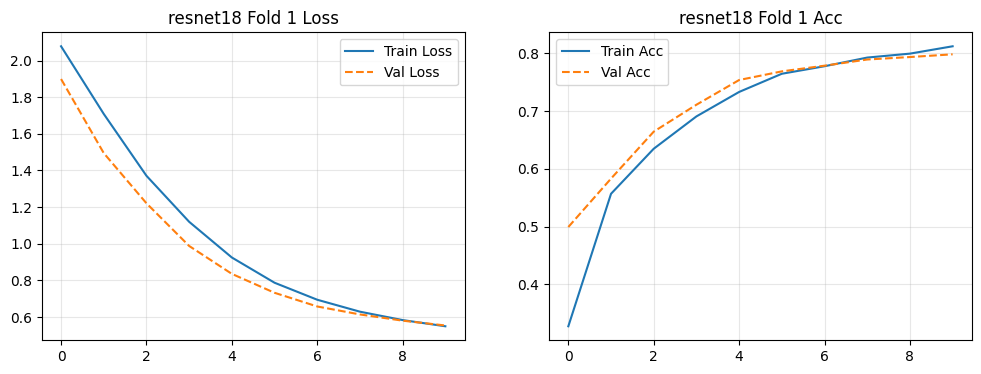

   -> Fold 1 Test Acc: 0.8011 | F1: 0.7469

🔄 FOLD 2/5...


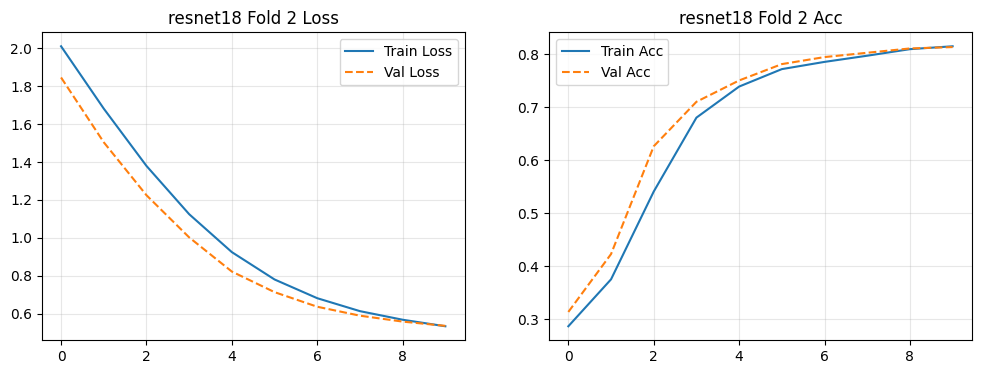

   -> Fold 2 Test Acc: 0.8030 | F1: 0.7556

🔄 FOLD 3/5...


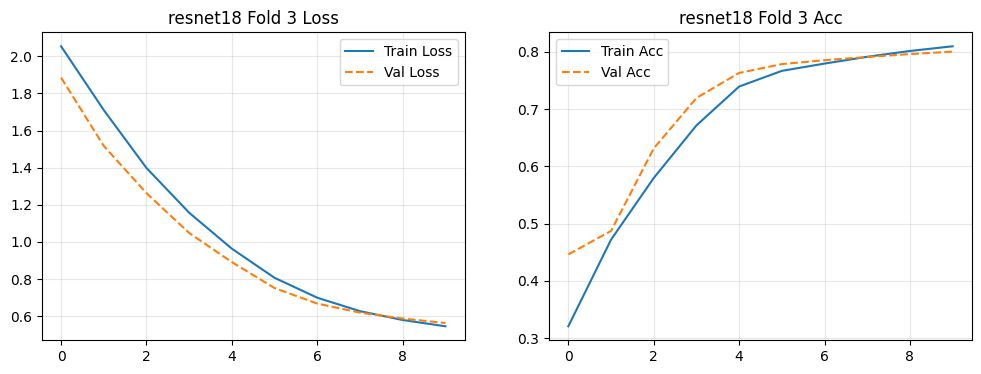

   -> Fold 3 Test Acc: 0.8120 | F1: 0.7624

🔄 FOLD 4/5...


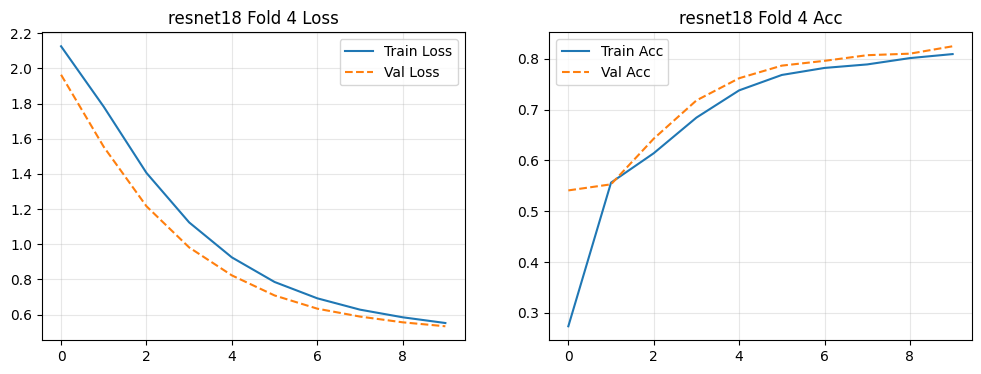

   -> Fold 4 Test Acc: 0.7982 | F1: 0.7424

🔄 FOLD 5/5...


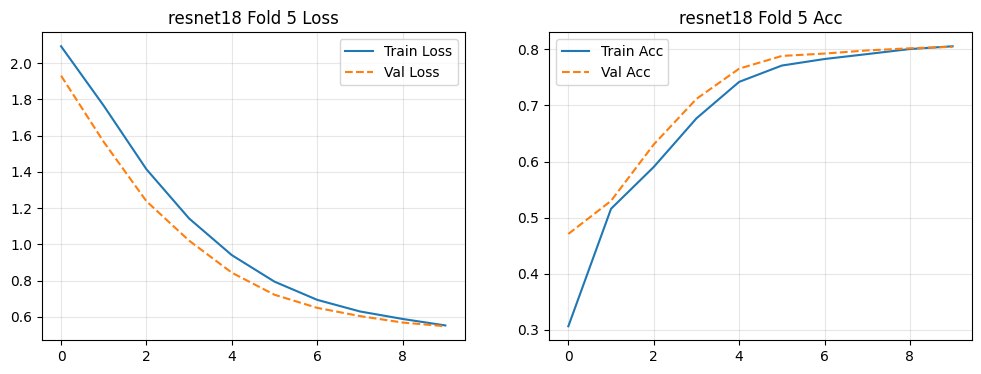

   -> Fold 5 Test Acc: 0.7988 | F1: 0.7470

🏆 RESNET18 SONUÇ TABLOSU (Kılavuza Uygun)
          Metric    Fold1    Fold2    Fold3    Fold4    Fold5      Mean ± Std
        Accuracy 0.801091 0.803016 0.811999 0.798203 0.798845 0.8026 ± 0.0050
F1-Score (Macro) 0.746904 0.755559 0.762356 0.742427 0.746988 0.7508 ± 0.0072


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score, f1_score
from tqdm import tqdm
import numpy as np
import pandas as pd
import os
import gc
import timm
import copy
import matplotlib.pyplot as plt

# --- AYARLAR ---
BASE_PATH = '/content/drive/MyDrive/Deep-Learning'
BATCH_SIZE = 256
EPOCHS = 10
N_FOLDS = 5
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
MODEL_NAME = 'resnet18'

# --- DATASET ---
class PureImageDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = torch.LongTensor(labels)
        self.transform = transform
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        img = self.images[idx]
        if self.transform: img = self.transform(img)
        return img, self.labels[idx]

def get_transforms():
    return transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

# --- MODEL ---
class SingleModalityImageModel(nn.Module):
    def __init__(self, model_name, num_classes=9):
        super(SingleModalityImageModel, self).__init__()
        self.backbone = timm.create_model(model_name, pretrained=True, num_classes=num_classes)
    def forward(self, x): return self.backbone(x)

# --- GRAFİK ---
def show_plot(train_losses, val_losses, train_accs, val_accs, fold_num, model_name):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss'); plt.plot(val_losses, label='Val Loss', linestyle='--')
    plt.title(f'{model_name} Fold {fold_num} Loss'); plt.legend(); plt.grid(True, alpha=0.3)
    plt.subplot(1, 2, 2)
    plt.plot(train_accs, label='Train Acc'); plt.plot(val_accs, label='Val Acc', linestyle='--')
    plt.title(f'{model_name} Fold {fold_num} Acc'); plt.legend(); plt.grid(True, alpha=0.3)
    plt.show()

# --- ÇALIŞTIRMA ---
def run_resnet():
    print(f"🚀 {MODEL_NAME.upper()} EĞİTİMİ BAŞLIYOR...")

    # Veri Yükleme
    X_img = np.load(os.path.join(BASE_PATH, 'X_images_uint8.npy'), mmap_mode='r')
    y = np.load(os.path.join(BASE_PATH, 'y_labels.npy'))

    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
    fold_accs = []
    fold_f1s = []

    for fold, (train_val_idx, test_idx) in enumerate(skf.split(X_img, y)):
        print(f"\n🔄 FOLD {fold+1}/{N_FOLDS}...")
        inner_train_idx, inner_val_idx = train_test_split(train_val_idx, test_size=0.1875, stratify=y[train_val_idx], random_state=42)

        train_ds = PureImageDataset(X_img[inner_train_idx], y[inner_train_idx], transform=get_transforms())
        val_ds = PureImageDataset(X_img[inner_val_idx], y[inner_val_idx], transform=get_transforms())
        test_ds = PureImageDataset(X_img[test_idx], y[test_idx], transform=get_transforms())

        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
        val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
        test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

        model = SingleModalityImageModel(MODEL_NAME).to(DEVICE)
        optimizer = optim.Adam(model.parameters(), lr=5e-5)
        criterion = nn.CrossEntropyLoss()

        best_acc = 0.0; best_wts = copy.deepcopy(model.state_dict())
        H = {'tl':[], 'vl':[], 'ta':[], 'va':[]}

        for ep in range(EPOCHS):
            model.train(); rl, cor, tot = 0.0, 0, 0
            for i, l in tqdm(train_loader, desc=f"Ep {ep+1}", leave=False):
                i, l = i.to(DEVICE), l.to(DEVICE)
                optimizer.zero_grad(); out = model(i); loss = criterion(out, l); loss.backward(); optimizer.step()
                rl+=loss.item()*i.size(0); _, p=torch.max(out, 1); tot+=l.size(0); cor+=(p==l).sum().item()
            H['tl'].append(rl/tot); H['ta'].append(cor/tot)

            model.eval(); vl, vcor, vtot = 0.0, 0, 0
            with torch.no_grad():
                for i, l in val_loader:
                    i, l = i.to(DEVICE), l.to(DEVICE)
                    out = model(i); vl+=criterion(out, l).item()*i.size(0); _, p=torch.max(out, 1); vtot+=l.size(0); vcor+=(p==l).sum().item()
            vacc = vcor/vtot; H['vl'].append(vl/vtot); H['va'].append(vacc)
            if vacc > best_acc: best_acc=vacc; best_wts=copy.deepcopy(model.state_dict())

        show_plot(H['tl'], H['vl'], H['ta'], H['va'], fold+1, MODEL_NAME)

        # TEST
        model.load_state_dict(best_wts); model.eval()
        preds, trues = [], []
        with torch.no_grad():
            for i, l in test_loader:
                _, p = torch.max(model(i.to(DEVICE)), 1)
                preds.extend(p.cpu().numpy()); trues.extend(l.cpu().numpy())

        acc = accuracy_score(trues, preds)
        f1 = f1_score(trues, preds, average='macro')
        fold_accs.append(acc); fold_f1s.append(f1)
        print(f"   -> Fold {fold+1} Test Acc: {acc:.4f} | F1: {f1:.4f}")

        del model, train_loader, val_loader, test_loader; gc.collect(); torch.cuda.empty_cache()

    # --- TABLO ÇIKTISI ---
    print("\n" + "="*85)
    print(f"🏆 {MODEL_NAME.upper()} SONUÇ TABLOSU (Kılavuza Uygun)")
    print("="*85)

    mean_acc, std_acc = np.mean(fold_accs), np.std(fold_accs)
    mean_f1, std_f1 = np.mean(fold_f1s), np.std(fold_f1s)

    results = {
        'Metric': ['Accuracy', 'F1-Score (Macro)'],
        'Fold1': [fold_accs[0], fold_f1s[0]],
        'Fold2': [fold_accs[1], fold_f1s[1]],
        'Fold3': [fold_accs[2], fold_f1s[2]],
        'Fold4': [fold_accs[3], fold_f1s[3]],
        'Fold5': [fold_accs[4], fold_f1s[4]],
        'Mean ± Std': [f"{mean_acc:.4f} ± {std_acc:.4f}", f"{mean_f1:.4f} ± {std_f1:.4f}"]
    }

    df = pd.DataFrame(results)
    print(df.to_string(index=False))
    print("="*85)

if __name__ == "__main__":
    run_resnet()

**ViT Transformer**

🚀 vit_base_patch16_224 EĞİTİMİ BAŞLIYOR...

🔄 FOLD 1/5...


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

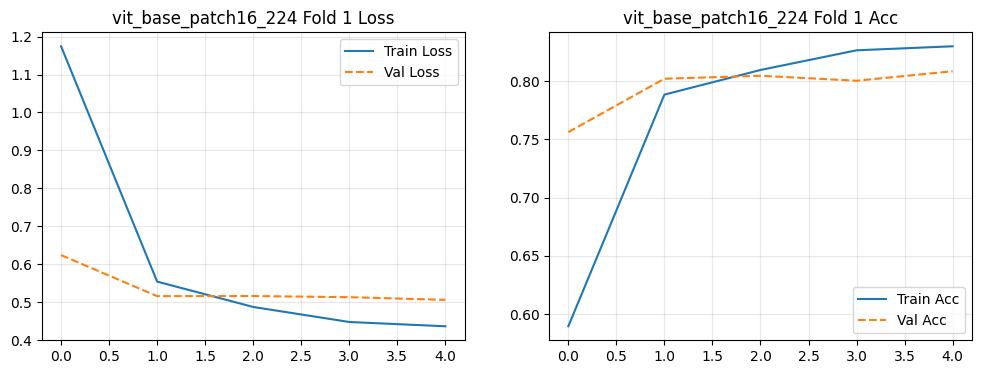

   -> Fold 1 Test Acc: 0.8104 | F1: 0.7712

🔄 FOLD 2/5...


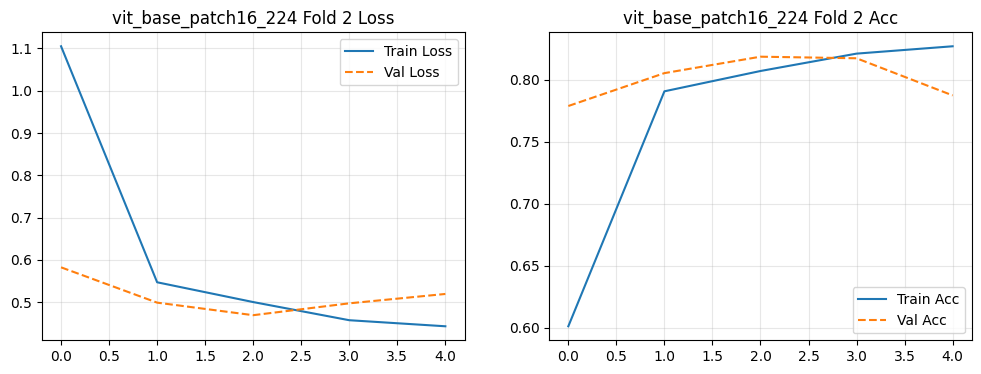

   -> Fold 2 Test Acc: 0.8081 | F1: 0.7624

🔄 FOLD 3/5...


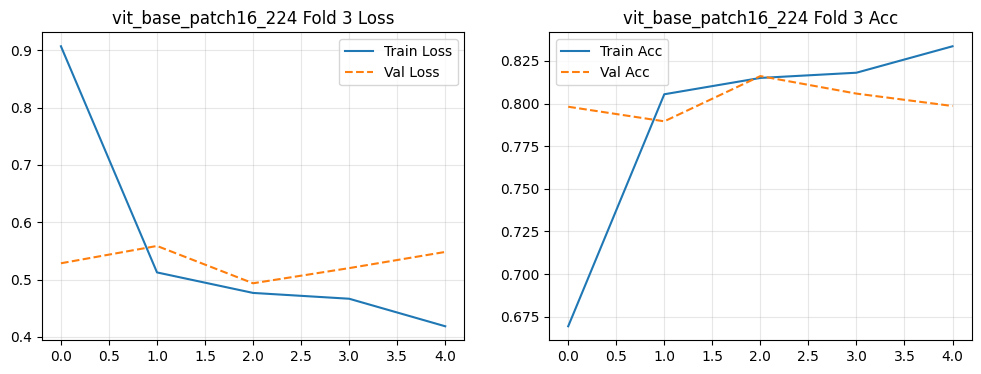

   -> Fold 3 Test Acc: 0.8213 | F1: 0.7768

🔄 FOLD 4/5...


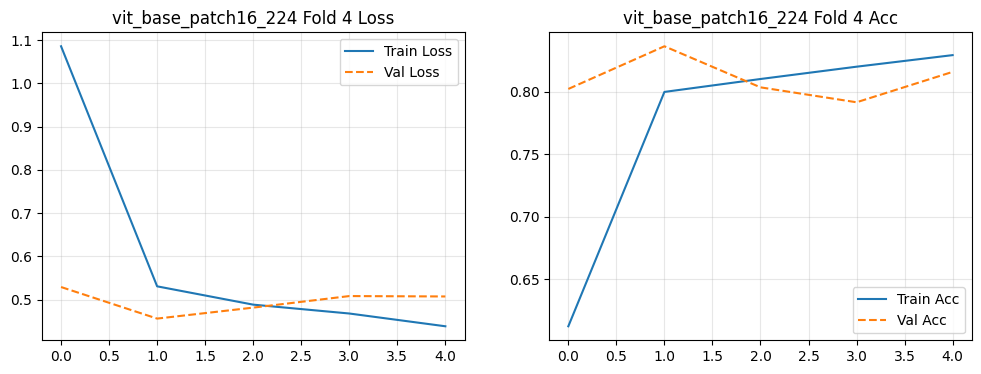

   -> Fold 4 Test Acc: 0.8104 | F1: 0.7661

🔄 FOLD 5/5...


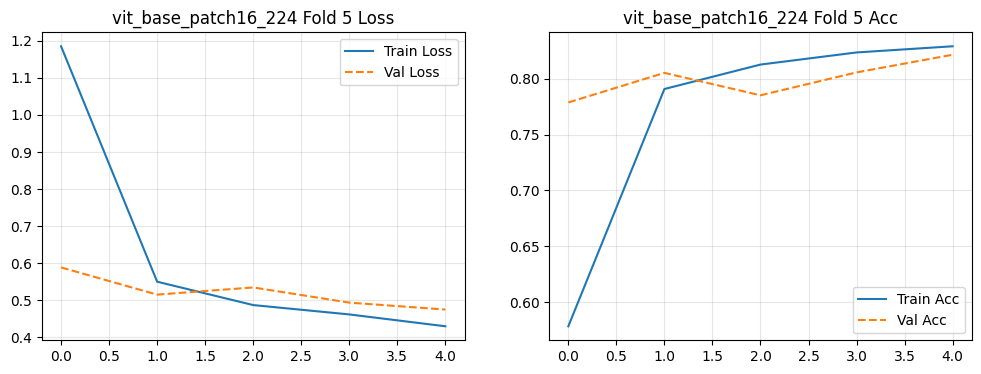

   -> Fold 5 Test Acc: 0.8158 | F1: 0.7834

🏆 vit_base_patch16_224 SONUÇ TABLOSU
          Metric    Fold1    Fold2    Fold3    Fold4    Fold5      Mean ± Std
        Accuracy 0.810395 0.808149 0.821303 0.810395 0.815849 0.8132 ± 0.0048
F1-Score (Macro) 0.771187 0.762429 0.776816 0.766090 0.783436 0.7720 ± 0.0075


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score, f1_score
from tqdm import tqdm
import numpy as np
import pandas as pd
import os
import gc
import timm
import copy
import matplotlib.pyplot as plt

# --- AYARLAR ---
BASE_PATH = '/content/drive/MyDrive/Deep-Learning'
BATCH_SIZE = 256
EPOCHS = 5
N_FOLDS = 5
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
MODEL_NAME = 'vit_base_patch16_224'

class PureImageDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = torch.LongTensor(labels)
        self.transform = transform
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        img = self.images[idx]
        if self.transform: img = self.transform(img)
        return img, self.labels[idx]

def get_transforms():
    return transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

class SingleModalityImageModel(nn.Module):
    def __init__(self, model_name, num_classes=9):
        super(SingleModalityImageModel, self).__init__()
        self.backbone = timm.create_model(model_name, pretrained=True, num_classes=num_classes)
    def forward(self, x): return self.backbone(x)

def show_plot(train_losses, val_losses, train_accs, val_accs, fold_num, model_name):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss'); plt.plot(val_losses, label='Val Loss', linestyle='--')
    plt.title(f'{model_name} Fold {fold_num} Loss'); plt.legend(); plt.grid(True, alpha=0.3)
    plt.subplot(1, 2, 2)
    plt.plot(train_accs, label='Train Acc'); plt.plot(val_accs, label='Val Acc', linestyle='--')
    plt.title(f'{model_name} Fold {fold_num} Acc'); plt.legend(); plt.grid(True, alpha=0.3)
    plt.show()

def run_vit():
    print(f"🚀 {MODEL_NAME} EĞİTİMİ BAŞLIYOR...")
    X_img = np.load(os.path.join(BASE_PATH, 'X_images_uint8.npy'), mmap_mode='r')
    y = np.load(os.path.join(BASE_PATH, 'y_labels.npy'))
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
    fold_accs = []; fold_f1s = []

    for fold, (train_val_idx, test_idx) in enumerate(skf.split(X_img, y)):
        print(f"\n🔄 FOLD {fold+1}/{N_FOLDS}...")
        inner_train_idx, inner_val_idx = train_test_split(train_val_idx, test_size=0.1875, stratify=y[train_val_idx], random_state=42)
        train_ds = PureImageDataset(X_img[inner_train_idx], y[inner_train_idx], transform=get_transforms())
        val_ds = PureImageDataset(X_img[inner_val_idx], y[inner_val_idx], transform=get_transforms())
        test_ds = PureImageDataset(X_img[test_idx], y[test_idx], transform=get_transforms())

        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
        val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
        test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

        model = SingleModalityImageModel(MODEL_NAME).to(DEVICE)
        optimizer = optim.Adam(model.parameters(), lr=5e-5)
        criterion = nn.CrossEntropyLoss()
        best_acc = 0.0; best_wts = copy.deepcopy(model.state_dict()); H = {'tl':[], 'vl':[], 'ta':[], 'va':[]}

        for ep in range(EPOCHS):
            model.train(); rl, cor, tot = 0.0, 0, 0
            for i, l in tqdm(train_loader, desc=f"Ep {ep+1}", leave=False):
                i, l = i.to(DEVICE), l.to(DEVICE)
                optimizer.zero_grad(); out = model(i); loss = criterion(out, l); loss.backward(); optimizer.step()
                rl+=loss.item()*i.size(0); _, p=torch.max(out, 1); tot+=l.size(0); cor+=(p==l).sum().item()
            H['tl'].append(rl/tot); H['ta'].append(cor/tot)
            model.eval(); vl, vcor, vtot = 0.0, 0, 0
            with torch.no_grad():
                for i, l in val_loader:
                    i, l = i.to(DEVICE), l.to(DEVICE)
                    out = model(i); vl+=criterion(out, l).item()*i.size(0); _, p=torch.max(out, 1); vtot+=l.size(0); vcor+=(p==l).sum().item()
            vacc = vcor/vtot; H['vl'].append(vl/vtot); H['va'].append(vacc)
            if vacc > best_acc: best_acc=vacc; best_wts=copy.deepcopy(model.state_dict())

        show_plot(H['tl'], H['vl'], H['ta'], H['va'], fold+1, MODEL_NAME)
        model.load_state_dict(best_wts); model.eval(); preds, trues = [], []
        with torch.no_grad():
            for i, l in test_loader:
                _, p = torch.max(model(i.to(DEVICE)), 1)
                preds.extend(p.cpu().numpy()); trues.extend(l.cpu().numpy())
        acc = accuracy_score(trues, preds); f1 = f1_score(trues, preds, average='macro')
        fold_accs.append(acc); fold_f1s.append(f1)
        print(f"   -> Fold {fold+1} Test Acc: {acc:.4f} | F1: {f1:.4f}")
        del model, train_loader, val_loader, test_loader; gc.collect(); torch.cuda.empty_cache()

    print("\n" + "="*85)
    print(f"🏆 {MODEL_NAME} SONUÇ TABLOSU")
    print("="*85)
    mean_acc, std_acc = np.mean(fold_accs), np.std(fold_accs)
    mean_f1, std_f1 = np.mean(fold_f1s), np.std(fold_f1s)
    results = {
        'Metric': ['Accuracy', 'F1-Score (Macro)'],
        'Fold1': [fold_accs[0], fold_f1s[0]], 'Fold2': [fold_accs[1], fold_f1s[1]],
        'Fold3': [fold_accs[2], fold_f1s[2]], 'Fold4': [fold_accs[3], fold_f1s[3]], 'Fold5': [fold_accs[4], fold_f1s[4]],
        'Mean ± Std': [f"{mean_acc:.4f} ± {std_acc:.4f}", f"{mean_f1:.4f} ± {std_f1:.4f}"]
    }
    print(pd.DataFrame(results).to_string(index=False))
    print("="*85)

if __name__ == "__main__":
    run_vit()

**Swin Transformer**

🚀 swin_tiny_patch4_window7_224 EĞİTİMİ BAŞLIYOR...

🔄 FOLD 1/5...


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

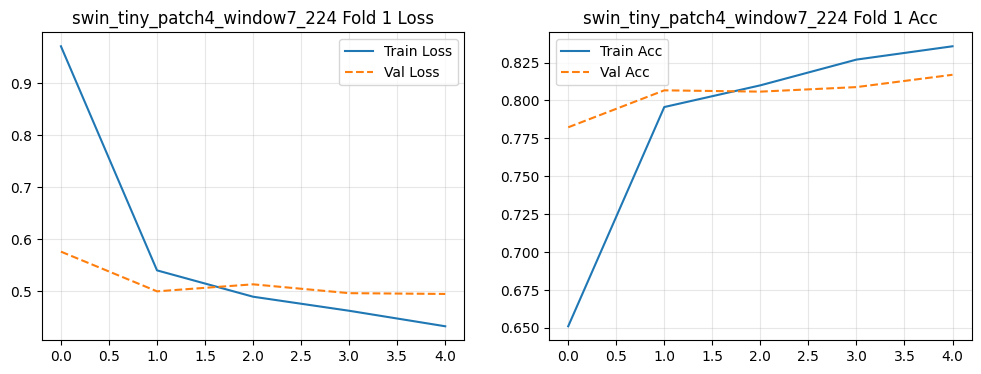

   -> Fold 1 Test Acc: 0.8175 | F1: 0.7785

🔄 FOLD 2/5...


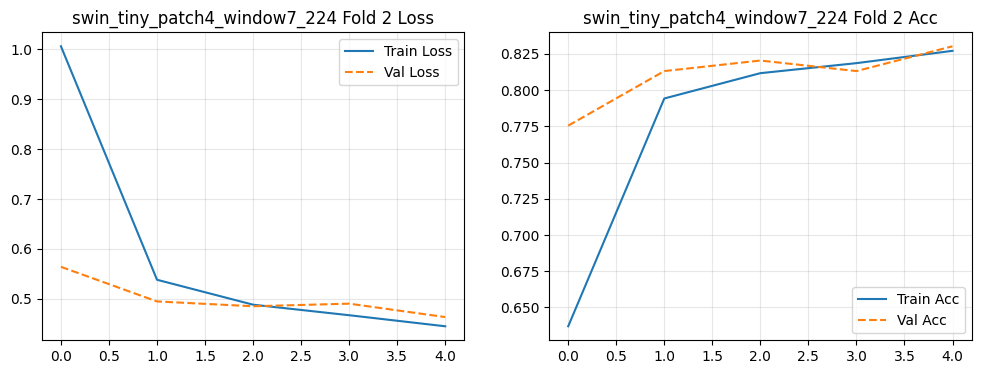

   -> Fold 2 Test Acc: 0.8110 | F1: 0.7753

🔄 FOLD 3/5...


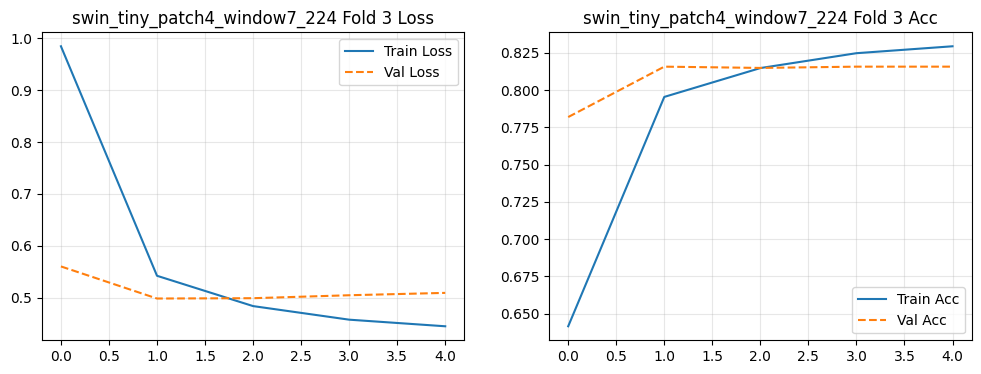

   -> Fold 3 Test Acc: 0.8229 | F1: 0.7773

🔄 FOLD 4/5...


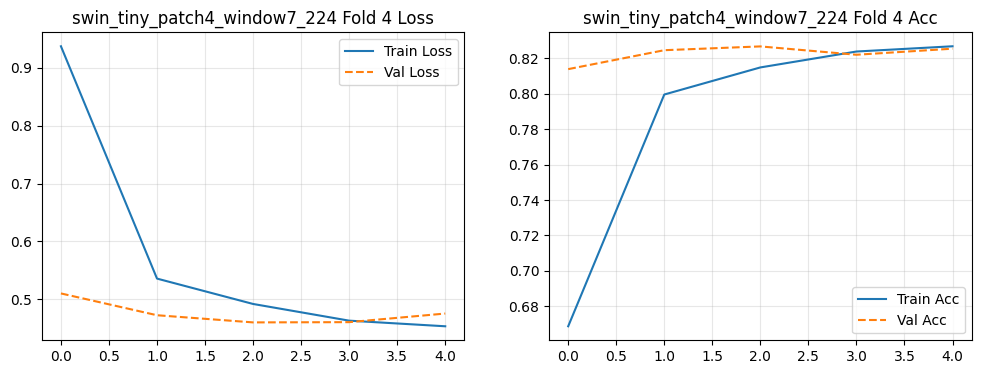

   -> Fold 4 Test Acc: 0.8126 | F1: 0.7683

🔄 FOLD 5/5...


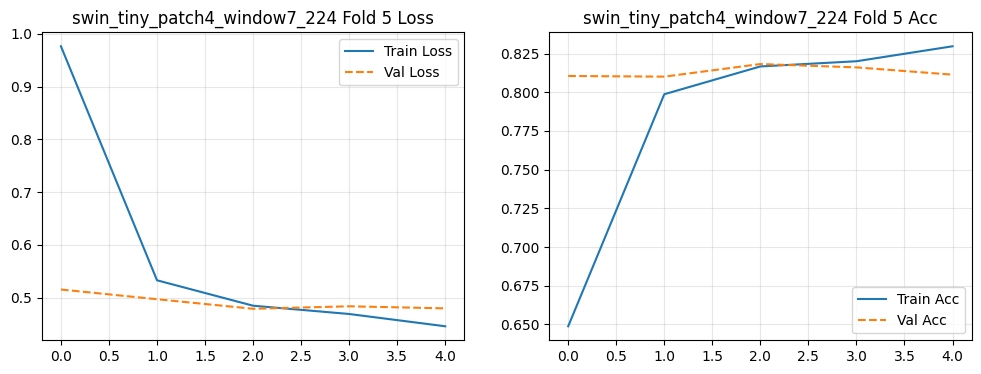

   -> Fold 5 Test Acc: 0.8098 | F1: 0.7588

🏆 swin_tiny_patch4_window7_224 SONUÇ TABLOSU
          Metric    Fold1    Fold2    Fold3    Fold4    Fold5      Mean ± Std
        Accuracy 0.817453 0.811036 0.822907 0.812640 0.809753 0.8148 ± 0.0048
F1-Score (Macro) 0.778469 0.775319 0.777295 0.768269 0.758765 0.7716 ± 0.0073


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score, f1_score
from tqdm import tqdm
import numpy as np
import pandas as pd
import os
import gc
import timm
import copy
import matplotlib.pyplot as plt

# --- AYARLAR ---
BASE_PATH = '/content/drive/MyDrive/Deep-Learning'
BATCH_SIZE = 256
EPOCHS = 5
N_FOLDS = 5
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
MODEL_NAME = 'swin_tiny_patch4_window7_224'

class PureImageDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = torch.LongTensor(labels)
        self.transform = transform
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        img = self.images[idx]
        if self.transform: img = self.transform(img)
        return img, self.labels[idx]

def get_transforms():
    return transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

class SingleModalityImageModel(nn.Module):
    def __init__(self, model_name, num_classes=9):
        super(SingleModalityImageModel, self).__init__()
        self.backbone = timm.create_model(model_name, pretrained=True, num_classes=num_classes)
    def forward(self, x): return self.backbone(x)

def show_plot(train_losses, val_losses, train_accs, val_accs, fold_num, model_name):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss'); plt.plot(val_losses, label='Val Loss', linestyle='--')
    plt.title(f'{model_name} Fold {fold_num} Loss'); plt.legend(); plt.grid(True, alpha=0.3)
    plt.subplot(1, 2, 2)
    plt.plot(train_accs, label='Train Acc'); plt.plot(val_accs, label='Val Acc', linestyle='--')
    plt.title(f'{model_name} Fold {fold_num} Acc'); plt.legend(); plt.grid(True, alpha=0.3)
    plt.show()

def run_swin():
    print(f"🚀 {MODEL_NAME} EĞİTİMİ BAŞLIYOR...")
    X_img = np.load(os.path.join(BASE_PATH, 'X_images_uint8.npy'), mmap_mode='r')
    y = np.load(os.path.join(BASE_PATH, 'y_labels.npy'))
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
    fold_accs = []; fold_f1s = []

    for fold, (train_val_idx, test_idx) in enumerate(skf.split(X_img, y)):
        print(f"\n🔄 FOLD {fold+1}/{N_FOLDS}...")
        inner_train_idx, inner_val_idx = train_test_split(train_val_idx, test_size=0.1875, stratify=y[train_val_idx], random_state=42)
        train_ds = PureImageDataset(X_img[inner_train_idx], y[inner_train_idx], transform=get_transforms())
        val_ds = PureImageDataset(X_img[inner_val_idx], y[inner_val_idx], transform=get_transforms())
        test_ds = PureImageDataset(X_img[test_idx], y[test_idx], transform=get_transforms())

        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
        val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
        test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

        model = SingleModalityImageModel(MODEL_NAME).to(DEVICE)
        optimizer = optim.Adam(model.parameters(), lr=5e-5)
        criterion = nn.CrossEntropyLoss()
        best_acc = 0.0; best_wts = copy.deepcopy(model.state_dict()); H = {'tl':[], 'vl':[], 'ta':[], 'va':[]}

        for ep in range(EPOCHS):
            model.train(); rl, cor, tot = 0.0, 0, 0
            for i, l in tqdm(train_loader, desc=f"Ep {ep+1}", leave=False):
                i, l = i.to(DEVICE), l.to(DEVICE)
                optimizer.zero_grad(); out = model(i); loss = criterion(out, l); loss.backward(); optimizer.step()
                rl+=loss.item()*i.size(0); _, p=torch.max(out, 1); tot+=l.size(0); cor+=(p==l).sum().item()
            H['tl'].append(rl/tot); H['ta'].append(cor/tot)
            model.eval(); vl, vcor, vtot = 0.0, 0, 0
            with torch.no_grad():
                for i, l in val_loader:
                    i, l = i.to(DEVICE), l.to(DEVICE)
                    out = model(i); vl+=criterion(out, l).item()*i.size(0); _, p=torch.max(out, 1); vtot+=l.size(0); vcor+=(p==l).sum().item()
            vacc = vcor/vtot; H['vl'].append(vl/vtot); H['va'].append(vacc)
            if vacc > best_acc: best_acc=vacc; best_wts=copy.deepcopy(model.state_dict())

        show_plot(H['tl'], H['vl'], H['ta'], H['va'], fold+1, MODEL_NAME)
        model.load_state_dict(best_wts); model.eval(); preds, trues = [], []
        with torch.no_grad():
            for i, l in test_loader:
                _, p = torch.max(model(i.to(DEVICE)), 1)
                preds.extend(p.cpu().numpy()); trues.extend(l.cpu().numpy())
        acc = accuracy_score(trues, preds); f1 = f1_score(trues, preds, average='macro')
        fold_accs.append(acc); fold_f1s.append(f1)
        print(f"   -> Fold {fold+1} Test Acc: {acc:.4f} | F1: {f1:.4f}")
        del model, train_loader, val_loader, test_loader; gc.collect(); torch.cuda.empty_cache()

    print("\n" + "="*85)
    print(f"🏆 {MODEL_NAME} SONUÇ TABLOSU")
    print("="*85)
    mean_acc, std_acc = np.mean(fold_accs), np.std(fold_accs)
    mean_f1, std_f1 = np.mean(fold_f1s), np.std(fold_f1s)
    results = {
        'Metric': ['Accuracy', 'F1-Score (Macro)'],
        'Fold1': [fold_accs[0], fold_f1s[0]], 'Fold2': [fold_accs[1], fold_f1s[1]],
        'Fold3': [fold_accs[2], fold_f1s[2]], 'Fold4': [fold_accs[3], fold_f1s[3]], 'Fold5': [fold_accs[4], fold_f1s[4]],
        'Mean ± Std': [f"{mean_acc:.4f} ± {std_acc:.4f}", f"{mean_f1:.4f} ± {std_f1:.4f}"]
    }
    print(pd.DataFrame(results).to_string(index=False))
    print("="*85)

if __name__ == "__main__":
    run_swin()

**MLP/TabTransformer/FT-Transformer**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
from tqdm import tqdm
import numpy as np
import os
import copy
import math

# --- AYARLAR ---
BASE_PATH = '/content/drive/MyDrive/Deep-Learning'
BATCH_SIZE = 256
EPOCHS = 10
N_FOLDS = 5
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# --- 1. MODEL: MLP (Derin Öğrenme Temsilcisi) ---
class MLPModel(nn.Module):
    def __init__(self, input_dim=27, num_classes=9):
        super(MLPModel, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )
    def forward(self, x): return self.net(x)

# --- 2. MODEL: Tabular Transformer (Transformer 1) ---
class TabTransformer(nn.Module):
    def __init__(self, input_dim=27, num_classes=9, d_model=32, nhead=4, num_layers=2):
        super(TabTransformer, self).__init__()
        self.embedding = nn.Linear(1, d_model)
        self.encoder = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=64, batch_first=True),
            num_layers=num_layers
        )
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        self.classifier = nn.Linear(d_model, num_classes)

    def forward(self, x):
        # (Batch, 27) -> (Batch, 27, 1) -> (Batch, 27, d_model)
        x = self.embedding(x.unsqueeze(-1))
        cls_tokens = self.cls_token.expand(x.size(0), -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = self.encoder(x)
        return self.classifier(x[:, 0, :])

# --- 3. MODEL: FT-Transformer (Transformer 2 - Deep) ---
class FTTransformer(nn.Module):
    def __init__(self, input_dim=27, num_classes=9, d_model=64, nhead=8, num_layers=3):
        super(FTTransformer, self).__init__()
        self.embedding = nn.Sequential(nn.Linear(1, d_model), nn.ReLU(), nn.Linear(d_model, d_model))
        self.encoder = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=128, dropout=0.2, batch_first=True),
            num_layers=num_layers
        )
        self.classifier = nn.Sequential(nn.LayerNorm(d_model), nn.Linear(d_model, num_classes))

    def forward(self, x):
        x = self.embedding(x.unsqueeze(-1))
        x = self.encoder(x)
        return self.classifier(x.mean(dim=1)) # Average Pooling

# --- LİSTE ---
TABULAR_MODELS = [
    {'name': 'MLP (Deep Learning)', 'cls': MLPModel},
    {'name': 'TabTransformer (Transf. 1)', 'cls': TabTransformer},
    {'name': 'FT-Transformer (Transf. 2)', 'cls': FTTransformer}
]

# --- DATASET ---
class TabularDataset(Dataset):
    def __init__(self, stats, labels):
        self.stats = torch.FloatTensor(stats); self.labels = torch.LongTensor(labels)
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx): return self.stats[idx], self.labels[idx]

# --- EĞİTİM ---
def run_tabular_league():
    print(f"🚀 TABULAR MODALİTE BAŞLIYOR ({DEVICE})...")
    X_stats = np.load(os.path.join(BASE_PATH, 'X_stats.npy'))
    y = np.load(os.path.join(BASE_PATH, 'y_labels.npy'))
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

    results = {}

    for config in TABULAR_MODELS:
        name = config['name']

        print(f"\n▒▒▒ MODEL: {name} ▒▒▒")
        fold_accs, fold_f1s = [], []

        for fold, (train_val_idx, test_idx) in enumerate(skf.split(X_stats, y)):
            # Kılavuza uygun: Test ayrıldı, kalanı Train/Val bölüyoruz
            inner_train_idx, inner_val_idx = train_test_split(train_val_idx, test_size=0.1875, stratify=y[train_val_idx], random_state=42)

            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_stats[inner_train_idx])
            X_val = scaler.transform(X_stats[inner_val_idx])
            X_test = scaler.transform(X_stats[test_idx])

            train_loader = DataLoader(TabularDataset(X_train, y[inner_train_idx]), batch_size=BATCH_SIZE, shuffle=True)
            val_loader = DataLoader(TabularDataset(X_val, y[inner_val_idx]), batch_size=BATCH_SIZE, shuffle=False)
            test_loader = DataLoader(TabularDataset(X_test, y[test_idx]), batch_size=BATCH_SIZE, shuffle=False)

            model = config['cls'](input_dim=27, num_classes=9).to(DEVICE)
            optimizer = optim.Adam(model.parameters(), lr=1e-3 if 'MLP' in name else 5e-4)
            criterion = nn.CrossEntropyLoss()

            best_val_acc = 0.0
            best_wts = copy.deepcopy(model.state_dict())

            for epoch in range(EPOCHS):
                model.train()
                for s, l in train_loader:
                    optimizer.zero_grad(); loss = criterion(model(s.to(DEVICE)), l.to(DEVICE)); loss.backward(); optimizer.step()

                model.eval()
                correct, total = 0, 0
                with torch.no_grad():
                    for s, l in val_loader:
                        out = model(s.to(DEVICE))
                        _, p = torch.max(out, 1)
                        total += l.size(0); correct += (p == l.to(DEVICE)).sum().item()
                if (correct/total) > best_val_acc: best_val_acc = correct/total; best_wts = copy.deepcopy(model.state_dict())

            # FINAL TEST
            model.load_state_dict(best_wts)
            model.eval()
            preds, true_lbls = [], []
            with torch.no_grad():
                for s, l in test_loader:
                    out = model(s.to(DEVICE))
                    _, p = torch.max(out, 1)
                    preds.extend(p.cpu().numpy()); true_lbls.extend(l.cpu().numpy())

            acc = np.mean(np.array(preds) == np.array(true_lbls))
            f1 = f1_score(true_lbls, preds, average='macro')
            fold_accs.append(acc); fold_f1s.append(f1)
            print(f"   -> Fold {fold+1}: Acc={acc:.4f} | F1={f1:.4f}")

        results[name] = f"{np.mean(fold_accs):.4f} ± {np.std(fold_accs):.4f}"
        print(f"✅ {name} SONUÇ: {results[name]}")

    print("\n🏆 TABULAR SONUÇLARI")
    for k, v in results.items(): print(f"{k:<30} | {v}")

if __name__ == "__main__":
    run_tabular_league()

🚀 TABULAR MODALİTE BAŞLIYOR (cuda)...

▒▒▒ MODEL: MLP (Deep Learning) ▒▒▒
   -> Fold 1: Acc=0.6641 | F1=0.5519
   -> Fold 2: Acc=0.6769 | F1=0.5639
   -> Fold 3: Acc=0.6724 | F1=0.5512
   -> Fold 4: Acc=0.6583 | F1=0.5385
   -> Fold 5: Acc=0.6702 | F1=0.5506
✅ MLP (Deep Learning) SONUÇ: 0.6684 ± 0.0065

▒▒▒ MODEL: TabTransformer (Transf. 1) ▒▒▒
   -> Fold 1: Acc=0.4338 | F1=0.2491
   -> Fold 2: Acc=0.4434 | F1=0.2694
   -> Fold 3: Acc=0.4277 | F1=0.2474
   -> Fold 4: Acc=0.4142 | F1=0.2141
   -> Fold 5: Acc=0.4472 | F1=0.2497
✅ TabTransformer (Transf. 1) SONUÇ: 0.4332 ± 0.0118

▒▒▒ MODEL: FT-Transformer (Transf. 2) ▒▒▒
   -> Fold 1: Acc=0.4546 | F1=0.2871
   -> Fold 2: Acc=0.4456 | F1=0.2775
   -> Fold 3: Acc=0.4382 | F1=0.2758
   -> Fold 4: Acc=0.4447 | F1=0.2725
   -> Fold 5: Acc=0.4556 | F1=0.2985
✅ FT-Transformer (Transf. 2) SONUÇ: 0.4477 ± 0.0065

🏆 TABULAR SONUÇLARI
MLP (Deep Learning)            | 0.6684 ± 0.0065
TabTransformer (Transf. 1)     | 0.4332 ± 0.0118
FT-Transformer (T

-----------------------------------------

---------------------------------------

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report, f1_score
import numpy as np
import os
import timm
import copy
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- ORTAK AYARLAR ---
BASE_PATH = '/content/drive/MyDrive/Deep-Learning'
BATCH_SIZE = 1024
EPOCHS = 12
N_FOLDS = 5
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# Sonuçları saklayacağımız global sözlük
FINAL_RESULTS = {}
FOLD_RESULTS_TABLE = []

# --- DATASET ---
class FusionDataset(Dataset):
    def __init__(self, images, stats, labels, transform=None):
        self.images = images
        self.stats = torch.FloatTensor(stats)
        self.labels = torch.LongTensor(labels)
        self.transform = transform
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        img = self.images[idx]
        if self.transform: img = self.transform(img)
        return img, self.stats[idx], self.labels[idx]

def get_transforms():
    return transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

# --- 🛠️ GELİŞMİŞ METRİK VE RAPORLAMA ---
def log_fold_metrics(model_name, fold_accuracies, fold_f1s):
    """
    Kılavuzdaki 'Model Fold1 Fold2 ... Mean ± Std' tablosunu oluşturmak için veriyi kaydeder.
    """
    mean_acc = np.mean(fold_accuracies)
    std_acc = np.std(fold_accuracies)

    mean_f1 = np.mean(fold_f1s)
    std_f1 = np.std(fold_f1s)

    # Accuracy Satırı
    row_acc = {
        "Model": f"{model_name} (Acc)",
        "Fold1": fold_accuracies[0], "Fold2": fold_accuracies[1], "Fold3": fold_accuracies[2],
        "Fold4": fold_accuracies[3], "Fold5": fold_accuracies[4],
        "Mean ± Std": f"{mean_acc:.4f} ± {std_acc:.4f}"
    }
    FOLD_RESULTS_TABLE.append(row_acc)

    # F1 Satırı (Opsiyonel olarak tabloya eklenebilir veya ayrı tutulabilir)
    row_f1 = {
        "Model": f"{model_name} (F1)",
        "Fold1": fold_f1s[0], "Fold2": fold_f1s[1], "Fold3": fold_f1s[2],
        "Fold4": fold_f1s[3], "Fold5": fold_f1s[4],
        "Mean ± Std": f"{mean_f1:.4f} ± {std_f1:.4f}"
    }
    FOLD_RESULTS_TABLE.append(row_f1)

def calculate_final_metrics(model_name, y_true, y_pred):
    """
    Tüm foldların birleşimi (Cross-Validation sonucu) üzerinden genel metrikleri hesaplar.
    """
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)

    # Specificity Hesaplama
    cm = confusion_matrix(y_true, y_pred)
    specificities = []
    for i in range(len(cm)):
        tn = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])
        fp = cm[:, i].sum() - cm[i, i]
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0
        specificities.append(spec)
    avg_specificity = np.mean(specificities)

    print(f"\n📊 {model_name} GENEL PERFORMANS RAPORU:")
    print(f"• Accuracy:    {acc:.4f}")
    print(f"• F1-Score:    {f1:.4f} (Macro)")
    print(f"• Sensitivity: {rec:.4f} (Recall)")
    print(f"• Specificity: {avg_specificity:.4f}")

    FINAL_RESULTS[model_name] = {
        'Accuracy': acc,
        'F1-Score': f1,
        'Recall (Sens.)': rec,
        'Specificity': avg_specificity
    }

**EARLY FUSION**

In [ ]:
class EarlyFusionModel(nn.Module):
    def __init__(self, num_classes=9, num_tab_features=27):
        super(EarlyFusionModel, self).__init__()
        self.img_backbone = timm.create_model('resnet18', pretrained=True, num_classes=0)
        # ResNet18 çıkışı 512 + Tabular 27 -> MLP
        self.tab_backbone = nn.Sequential(nn.Linear(num_tab_features, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Linear(64, 32), nn.ReLU())
        self.classifier = nn.Sequential(nn.Linear(512 + 32, 256), nn.ReLU(), nn.Dropout(0.3), nn.Linear(256, num_classes))
    def forward(self, img, tab):
        # Concatenation (Birleştirme)
        return self.classifier(torch.cat((self.img_backbone(img), self.tab_backbone(tab)), dim=1))

def run_early_fusion():
    print(f"\n🚀 EARLY FUSION BAŞLIYOR...")
    X_img = np.load(os.path.join(BASE_PATH, 'X_images_uint8.npy'), mmap_mode='r')
    X_stats = np.load(os.path.join(BASE_PATH, 'X_stats.npy'))
    y = np.load(os.path.join(BASE_PATH, 'y_labels.npy'))

    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

    all_preds, all_trues = [], []
    fold_accs, fold_f1s = [], []

    for fold, (train_val_idx, test_idx) in enumerate(skf.split(X_img, y)):
        print(f"🔄 Fold {fold+1}/{N_FOLDS}...")

        # Train/Val ayrımı (Fold2-5 Train, Fold1 Test mantığı StratifiedKFold ile sağlanır)
        inner_train_idx, inner_val_idx = train_test_split(train_val_idx, test_size=0.1875, stratify=y[train_val_idx], random_state=42)

        scaler = StandardScaler()
        S_train = scaler.fit_transform(X_stats[inner_train_idx])
        S_val = scaler.transform(X_stats[inner_val_idx])
        S_test = scaler.transform(X_stats[test_idx])

        train_loader = DataLoader(FusionDataset(X_img[inner_train_idx], S_train, y[inner_train_idx], get_transforms()), batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
        val_loader = DataLoader(FusionDataset(X_img[inner_val_idx], S_val, y[inner_val_idx], get_transforms()), batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
        test_loader = DataLoader(FusionDataset(X_img[test_idx], S_test, y[test_idx], get_transforms()), batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

        model = EarlyFusionModel().to(DEVICE)
        optimizer = optim.Adam(model.parameters(), lr=5e-5)
        criterion = nn.CrossEntropyLoss()
        best_acc = 0.0; best_wts = copy.deepcopy(model.state_dict())

        for ep in range(EPOCHS):
            model.train()
            for i, s, l in train_loader:
                i, s, l = i.to(DEVICE), s.to(DEVICE), l.to(DEVICE)
                optimizer.zero_grad(); out = model(i, s); loss = criterion(out, l); loss.backward(); optimizer.step()

            # Validation
            model.eval(); correct, total = 0, 0
            with torch.no_grad():
                for i, s, l in val_loader:
                    i, s, l = i.to(DEVICE), s.to(DEVICE), l.to(DEVICE)
                    out = model(i, s); _, p = torch.max(out, 1); total += l.size(0); correct += (p == l).sum().item()
            if (correct/total) > best_acc: best_acc = correct/total; best_wts = copy.deepcopy(model.state_dict())

        # --- FOLD TEST RAPORU ---
        model.load_state_dict(best_wts)
        model.eval()
        fold_preds, fold_trues = [], []
        with torch.no_grad():
            for i, s, l in test_loader:
                _, p = torch.max(model(i.to(DEVICE), s.to(DEVICE)), 1)
                fold_preds.extend(p.cpu().numpy())
                fold_trues.extend(l.cpu().numpy())

        # Bu fold için metrikleri hesapla ve sakla
        f_acc = accuracy_score(fold_trues, fold_preds)
        f_f1 = f1_score(fold_trues, fold_preds, average='macro')
        fold_accs.append(f_acc)
        fold_f1s.append(f_f1)
        print(f"   -> Fold {fold+1} Acc: {f_acc:.4f} | F1: {f_f1:.4f}")

        # Genel metrikler için biriktir
        all_preds.extend(fold_preds)
        all_trues.extend(fold_trues)

    # Fold tablosunu doldur
    log_fold_metrics("Early Fusion", fold_accs, fold_f1s)
    # Genel metrikleri hesapla
    calculate_final_metrics("Early Fusion", np.array(all_trues), np.array(all_preds))

run_early_fusion()


🚀 EARLY FUSION BAŞLIYOR...
🔄 Fold 1/5...
   -> Fold 1 Acc: 0.6837 | F1: 0.5014
🔄 Fold 2/5...
   -> Fold 2 Acc: 0.6946 | F1: 0.5348
🔄 Fold 3/5...
   -> Fold 3 Acc: 0.6907 | F1: 0.5152
🔄 Fold 4/5...
   -> Fold 4 Acc: 0.6692 | F1: 0.4867
🔄 Fold 5/5...
   -> Fold 5 Acc: 0.6840 | F1: 0.5165

📊 Early Fusion GENEL PERFORMANS RAPORU:
• Accuracy:    0.6844
• F1-Score:    0.5151 (Macro)
• Sensitivity: 0.5603 (Recall)
• Specificity: 0.9592


**INTERMEDIATE FUSION**

In [ ]:
class IntermediateFusionModel(nn.Module):
    def __init__(self, num_classes=9, num_tab_features=27):
        super(IntermediateFusionModel, self).__init__()
        # ResNet'in 4. katmanından özellik haritasını alıyoruz (Feature Map)
        self.img_backbone = timm.create_model('resnet18', pretrained=True, features_only=True, out_indices=[4])
        self.tab_backbone = nn.Sequential(nn.Linear(num_tab_features, 128), nn.ReLU(), nn.Linear(128, 512))
        # Cross-Attention
        self.attention = nn.MultiheadAttention(embed_dim=512, num_heads=8, batch_first=True)
        self.classifier = nn.Sequential(nn.LayerNorm(512), nn.Linear(512, num_classes))
    def forward(self, img, tab):
        # Image: (Batch, 512, 7, 7) -> (Batch, 49, 512)
        f_img = self.img_backbone(img)[0].flatten(2).transpose(1, 2)
        # Tabular: (Batch, 512) -> (Batch, 1, 512)
        f_tab = self.tab_backbone(tab).unsqueeze(1)
        # Attention: Query=Tabular, Key=Image, Value=Image
        attn_out, _ = self.attention(query=f_tab, key=f_img, value=f_img)
        # Residual connection + Classify
        return self.classifier((attn_out + f_tab).squeeze(1))

def run_intermediate_fusion():
    print(f"\n🚀 INTERMEDIATE FUSION BAŞLIYOR...")
    X_img = np.load(os.path.join(BASE_PATH, 'X_images_uint8.npy'), mmap_mode='r')
    X_stats = np.load(os.path.join(BASE_PATH, 'X_stats.npy'))
    y = np.load(os.path.join(BASE_PATH, 'y_labels.npy'))

    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
    all_preds, all_trues = [], []
    fold_accs, fold_f1s = [], []

    for fold, (train_val_idx, test_idx) in enumerate(skf.split(X_img, y)):
        print(f"🔄 Fold {fold+1}/{N_FOLDS}...")
        inner_train_idx, inner_val_idx = train_test_split(train_val_idx, test_size=0.1875, stratify=y[train_val_idx], random_state=42)
        scaler = StandardScaler()
        S_train = scaler.fit_transform(X_stats[inner_train_idx])
        S_val = scaler.transform(X_stats[inner_val_idx])
        S_test = scaler.transform(X_stats[test_idx])

        train_loader = DataLoader(FusionDataset(X_img[inner_train_idx], S_train, y[inner_train_idx], get_transforms()), batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
        val_loader = DataLoader(FusionDataset(X_img[inner_val_idx], S_val, y[inner_val_idx], get_transforms()), batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
        test_loader = DataLoader(FusionDataset(X_img[test_idx], S_test, y[test_idx], get_transforms()), batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

        model = IntermediateFusionModel().to(DEVICE)
        optimizer = optim.Adam(model.parameters(), lr=5e-5)
        criterion = nn.CrossEntropyLoss()
        best_acc = 0.0; best_wts = copy.deepcopy(model.state_dict())

        for ep in range(EPOCHS):
            model.train()
            for i, s, l in train_loader:
                i, s, l = i.to(DEVICE), s.to(DEVICE), l.to(DEVICE)
                optimizer.zero_grad(); out = model(i, s); loss = criterion(out, l); loss.backward(); optimizer.step()
            model.eval(); correct, total = 0, 0
            with torch.no_grad():
                for i, s, l in val_loader:
                    i, s, l = i.to(DEVICE), s.to(DEVICE), l.to(DEVICE)
                    out = model(i, s); _, p = torch.max(out, 1); total += l.size(0); correct += (p == l).sum().item()
            if (correct/total) > best_acc: best_acc = correct/total; best_wts = copy.deepcopy(model.state_dict())

        model.load_state_dict(best_wts); model.eval()
        fold_preds, fold_trues = [], []
        with torch.no_grad():
            for i, s, l in test_loader:
                _, p = torch.max(model(i.to(DEVICE), s.to(DEVICE)), 1)
                fold_preds.extend(p.cpu().numpy()); fold_trues.extend(l.cpu().numpy())

        f_acc = accuracy_score(fold_trues, fold_preds)
        f_f1 = f1_score(fold_trues, fold_preds, average='macro')
        fold_accs.append(f_acc); fold_f1s.append(f_f1)
        print(f"   -> Fold {fold+1} Acc: {f_acc:.4f} | F1: {f_f1:.4f}")
        all_preds.extend(fold_preds); all_trues.extend(fold_trues)

    log_fold_metrics("Intermediate Fusion", fold_accs, fold_f1s)
    calculate_final_metrics("Intermediate Fusion", np.array(all_trues), np.array(all_preds))

run_intermediate_fusion()


🚀 INTERMEDIATE FUSION BAŞLIYOR...
🔄 Fold 1/5...
   -> Fold 1 Acc: 0.8130 | F1: 0.7644
🔄 Fold 2/5...
   -> Fold 2 Acc: 0.7992 | F1: 0.7463
🔄 Fold 3/5...
   -> Fold 3 Acc: 0.8107 | F1: 0.7564
🔄 Fold 4/5...
   -> Fold 4 Acc: 0.7947 | F1: 0.7386
🔄 Fold 5/5...
   -> Fold 5 Acc: 0.8098 | F1: 0.7628

📊 Intermediate Fusion GENEL PERFORMANS RAPORU:
• Accuracy:    0.8055
• F1-Score:    0.7540 (Macro)
• Sensitivity: 0.7481 (Recall)
• Specificity: 0.9754


**LATE FUSION**

In [ ]:
class LateFusionModel(nn.Module):
    def __init__(self, num_classes=9, num_tab_features=27):
        super(LateFusionModel, self).__init__()
        # İki bağımsız model
        self.img_model = timm.create_model('resnet18', pretrained=True, num_classes=num_classes)
        self.tab_model = nn.Sequential(nn.Linear(num_tab_features, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Linear(64, num_classes))
    def forward(self, img, tab):
        # Softmax Score Fusion (Averaging Logits/Probs)
        out_img = self.img_model(img)
        out_tab = self.tab_model(tab)
        return (out_img + out_tab) / 2

def run_late_fusion():
    print(f"\n🚀 LATE FUSION (Softmax Score) BAŞLIYOR...")
    X_img = np.load(os.path.join(BASE_PATH, 'X_images_uint8.npy'), mmap_mode='r')
    X_stats = np.load(os.path.join(BASE_PATH, 'X_stats.npy'))
    y = np.load(os.path.join(BASE_PATH, 'y_labels.npy'))

    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
    all_preds, all_trues = [], []
    fold_accs, fold_f1s = [], []

    for fold, (train_val_idx, test_idx) in enumerate(skf.split(X_img, y)):
        print(f"🔄 Fold {fold+1}/{N_FOLDS}...")
        inner_train_idx, inner_val_idx = train_test_split(train_val_idx, test_size=0.1875, stratify=y[train_val_idx], random_state=42)
        scaler = StandardScaler()
        S_train = scaler.fit_transform(X_stats[inner_train_idx])
        S_val = scaler.transform(X_stats[inner_val_idx])
        S_test = scaler.transform(X_stats[test_idx])

        train_loader = DataLoader(FusionDataset(X_img[inner_train_idx], S_train, y[inner_train_idx], get_transforms()), batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
        val_loader = DataLoader(FusionDataset(X_img[inner_val_idx], S_val, y[inner_val_idx], get_transforms()), batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
        test_loader = DataLoader(FusionDataset(X_img[test_idx], S_test, y[test_idx], get_transforms()), batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

        model = LateFusionModel().to(DEVICE)
        optimizer = optim.Adam(model.parameters(), lr=5e-5)
        criterion = nn.CrossEntropyLoss()
        best_acc = 0.0; best_wts = copy.deepcopy(model.state_dict())

        for ep in range(EPOCHS):
            model.train()
            for i, s, l in train_loader:
                i, s, l = i.to(DEVICE), s.to(DEVICE), l.to(DEVICE)
                optimizer.zero_grad(); out = model(i, s); loss = criterion(out, l); loss.backward(); optimizer.step()
            model.eval(); correct, total = 0, 0
            with torch.no_grad():
                for i, s, l in val_loader:
                    i, s, l = i.to(DEVICE), s.to(DEVICE), l.to(DEVICE)
                    out = model(i, s); _, p = torch.max(out, 1); total += l.size(0); correct += (p == l).sum().item()
            if (correct/total) > best_acc: best_acc = correct/total; best_wts = copy.deepcopy(model.state_dict())

        model.load_state_dict(best_wts); model.eval()
        fold_preds, fold_trues = [], []
        with torch.no_grad():
            for i, s, l in test_loader:
                _, p = torch.max(model(i.to(DEVICE), s.to(DEVICE)), 1)
                fold_preds.extend(p.cpu().numpy()); fold_trues.extend(l.cpu().numpy())

        f_acc = accuracy_score(fold_trues, fold_preds)
        f_f1 = f1_score(fold_trues, fold_preds, average='macro')
        fold_accs.append(f_acc); fold_f1s.append(f_f1)
        print(f"   -> Fold {fold+1} Acc: {f_acc:.4f} | F1: {f_f1:.4f}")
        all_preds.extend(fold_preds); all_trues.extend(fold_trues)

    log_fold_metrics("Late Fusion", fold_accs, fold_f1s)
    calculate_final_metrics("Late Fusion", np.array(all_trues), np.array(all_preds))

run_late_fusion()


🚀 LATE FUSION (Softmax Score) BAŞLIYOR...
🔄 Fold 1/5...
   -> Fold 1 Acc: 0.6635 | F1: 0.5111
🔄 Fold 2/5...
   -> Fold 2 Acc: 0.6182 | F1: 0.4520
🔄 Fold 3/5...
   -> Fold 3 Acc: 0.6574 | F1: 0.5003
🔄 Fold 4/5...
   -> Fold 4 Acc: 0.6965 | F1: 0.5469
🔄 Fold 5/5...
   -> Fold 5 Acc: 0.6282 | F1: 0.4428

📊 Late Fusion GENEL PERFORMANS RAPORU:
• Accuracy:    0.6527
• F1-Score:    0.4950 (Macro)
• Sensitivity: 0.5235 (Recall)
• Specificity: 0.9542


**SONUCLAR**

In [ ]:
# --- RAPORLAMA ---
print("\n" + "="*100)
print("🏆 TABLO 1: FOLD-BAZLI PERFORMANS (Mean ± Std)")
print("="*100)
df_folds = pd.DataFrame(FOLD_RESULTS_TABLE)
# Sütun sırasını düzenle
cols = ["Model", "Fold1", "Fold2", "Fold3", "Fold4", "Fold5", "Mean ± Std"]
df_folds = df_folds[cols]
print(df_folds.to_string(index=False))

print("\n" + "="*100)
print("🏆 TABLO 2: FUSION YÖNTEMLERİ KARŞILAŞTIRMA (Genel Metrikler)")
print("="*100)
df_final = pd.DataFrame(FINAL_RESULTS).T
df_final = df_final[['Accuracy', 'Recall (Sens.)', 'Specificity', 'F1-Score']]
print(df_final)
print("="*100)


🏆 TABLO 1: FOLD-BAZLI PERFORMANS (Mean ± Std)
                    Model    Fold1    Fold2    Fold3    Fold4    Fold5      Mean ± Std
       Early Fusion (Acc) 0.683670 0.694578 0.690728 0.669233 0.683991 0.6844 ± 0.0087
        Early Fusion (F1) 0.501415 0.534791 0.515170 0.486693 0.516460 0.5109 ± 0.0161
Intermediate Fusion (Acc) 0.812961 0.799166 0.810715 0.794674 0.809753 0.8055 ± 0.0072
 Intermediate Fusion (F1) 0.764442 0.746349 0.756412 0.738600 0.762779 0.7537 ± 0.0099
        Late Fusion (Acc) 0.663458 0.618223 0.657363 0.696503 0.628168 0.6527 ± 0.0277
         Late Fusion (F1) 0.511148 0.452028 0.500292 0.546907 0.442777 0.4906 ± 0.0386

🏆 TABLO 2: FUSION YÖNTEMLERİ KARŞILAŞTIRMA (Genel Metrikler)
                     Accuracy  Recall (Sens.)  Specificity  F1-Score
Early Fusion         0.684440        0.560320     0.959193  0.515085
Intermediate Fusion  0.805454        0.748085     0.975392  0.753988
Late Fusion          0.652743        0.523548     0.954225  0.495049
